# AdaBoost

### Important Details (Explained in the Context of Decision Trees and Random Forest)

- AdaBoost makes use of weak learners. In the context of decision trees, it is a single root with two leaves called a stump (just one split). Although each decision tree is obviously much less accurate than a fully built out tree, it turns out to be useful.
- In Random Forests, each constructed decision tree has equal weight. In AdaBoost, some stumps have more weight than others.
- In Random Forests, each decision tree is made independently from each other. In AdaBoost, they are tied. The errors that the first stump makes determines how the second stump is made. 

## Constructing AdaBoost

### Step 1: Create Sample Weights

We start by giving each example in the training set a sample weight that indicates how important it is to be correctly classified. At the start, all the samples get the same weight ($1 / N$). After we make the first stump, these weights will change.

### Step 2: Making the First Stump

We make the first stump much like we would the first split of a decision tree. We look through all the features and possible candidate splits, and pick the split with the most purity.

We determine how much say a stump has in the final classification based on how well it classifies the samples. The total error for a stump is the sum of the weights associated with the incorrectly classified samples (total error will always be between 0 and 1). 
$$
error = \sum_{i \in incorrect} weight_i
$$

Then, the amount of say the stump has is:

$$
\alpha (Amount Say) = \frac{1}{2} \ln(\frac{1 - error}{error})
$$

The graph is as follows:

C:\Users\Alexander Xu\AppData\Local\Temp\ipykernel_27964\4270740577.py:5: RuntimeWarning: divide by zero encountered in divide
  amount_say = (1 / 2) * np.log((1 - error) / error)
C:\Users\Alexander Xu\AppData\Local\Temp\ipykernel_27964\4270740577.py:5: RuntimeWarning: divide by zero encountered in log
  amount_say = (1 / 2) * np.log((1 - error) / error)


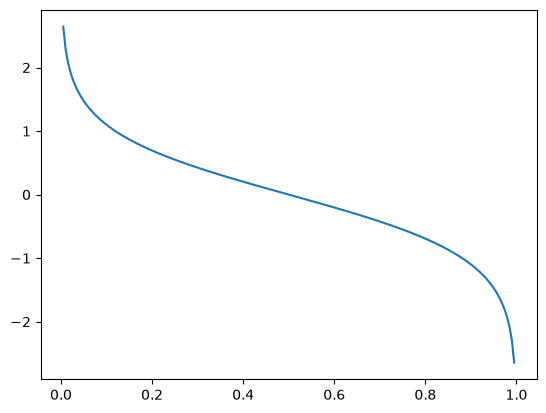

In [4]:

import matplotlib.pyplot as plt 
import numpy as np

error = np.linspace(0, 1, 200)
amount_say = (1 / 2) * np.log((1 - error) / error)
plt.plot(error, amount_say)
plt.show()


Note that if the error is very low (close to 0), the say is a large positive value. If it is close to a coin flip (0.5) the say is close to 0. If the error is very high (close to 1), the say is a large negative value.

### Updating the Weights

After constructing the first stump, we update the weights so that the training examples that were incorrectly classified by the first stump are emphasized. We update the sample weight according to:

$$
weight_{new} = weight \cdot e^{\alpha}
$$

Conceptually, this means that if the first stump did a good job classifying the training data (thus high $\alpha$), then we make the new sample weights of the ones it did not classify correctly much larger. If the stump did not do a good job, the change is much smaller. Then, for the examples that were classified correctly, we update according to this equation:

$$
weight_{new} = weight \cdot e^{-\alpha}
$$

In the same way, the more amount of say or the better the first stump was, the more we decrease those weights. 

After we've updated all the weights, we renormalize them so that they add up to 1 again (divide all by $\sum{weight_{new}}$)

### Creating the Second Stump

Now, we can use the updated weights to make the second stump. One way to do this is to do the same process as the first one, calculating Gini impurity values for each of the candidate splits. In this case, it would be a weighted Gini impurity score because we have assigned weights to all of the training samples. 

An alternative is to do random sampling. Based on the sample weights, we can create ranges (each range has length of the sample weight) where each corresponds to a train example.

For example, if we have example 1 with weight 0.3, example 2 with weight 0.5, and example 3 with 0.2, then we would say that the range 0-0.3 corresponds to example 1, 0.3-0.8 corresponds to example 2, and 0.8-1 corresponds to example 3.

Then, we would randomly generate values between 0 and 1 and inserting the corresponding example into a new dataset until the new dataset is the same length as the old dataset. Now, we've created a dataset where the weights of the original data is reflected in their frequency in the new dataset, and we can perform the split selection with regular Gini impurity.

We repeat this to create all our stumps. The amount of stumps we create is something that can be controlled and optimized via cross-validation.

## Making a Prediction

Now, when we want to make a prediction on test data, we feed each example through all of the decision stumps. Each of these stumps has an amount of say we calculated, and the output classification.

__We separate the trees by their output classification, and then add up the amount of say of all the trees for a specific output. The final predicted classification is simply the output that had the largest combined sum.__

## SAMME (Stagewise Additive Modeling using a Multiclass Exponential loss function)

Note that the equations of AdaBoost only work for binary classifications (yes/no, true/false). The extension to multi-classification is similar. The error equation is the same. The main change is how the amount of say is calculated. In AdaBoost, we designed the equation so that at a weighted error of 0.5, the amount of say is 0, because it is equivalent to a coin flip (pure randomness). However, for classification tasks with $K > 2$ classes, the random expected error is not 0.5 but $\frac{K-1}{K}$. Any error better than this is an improvement. The amount of say equation for muilti-class AdaBoost (called SAMME) is:

$$
\alpha = \ln \left(\frac{1 - err}{err} \right) + \ln(K-1)
$$

Note that plugging in $\frac{K-1}{K}$ for error gives $\ln(1) = 0$, so it still gives a say of 0 when the error is equivalent to randomness.

Also, for SAMME, we usually only increase weights for incorrect classifications, and don't decrease weights for correct classifications. 